In [1]:
# function to calculate the autopet3_py metrics 

# Method to get the lesion metrics and save as a csv

In [1]:

import os
import glob
import json
import pickle

import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk

import numpy as np
import nibabel as nib
import pathlib as plb
import cc3d
import csv
import sys

import argparse

def handle_arguments():
    """
    Handle command line arguments for processing images.
    """
    parser = argparse.ArgumentParser(description='Process probability analysis with various options')
    parser.add_argument('-k', '--key', type=str, default='*', 
                       help='Key pattern for file matching (default: *)')
    parser.add_argument('-l', '--lesion-only', action='store_true', 
                       help='Process only lesion data, skip CTImage object creation')
    parser.add_argument('-f', '--fold', type=str, default='comb', 
                       help='Fold name/number (default: 1)')
    parser.add_argument('-s', '--skip-existing', action='store_true',
                       help='Skip processing files that have already been processed', default=False)
    parser.add_argument('-i', '--image-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/imagesTr/", help='Directory containing images (default: ../imagesTr/)')
    parser.add_argument('-m', '--mets-only', action='store_true', 
                       help='Process only mets data, skip lesion-only data')
    parser.add_argument('-ld', '--label-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/", help='Directory containing labels (default: ../labelsTr/)') 
    parser.add_argument('-b', '--bone-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/Biratal/bone-metastasis/totalsegmentator/bone_segmentations_fold1/", help='Directory containing bone segmentations (default: ../totalsegmentator/bone_segmentations_fold1/)')

    parser.add_argument('-p', '--pred-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/test_predictions/", 
                        help='Directory containing prediction files (default: //dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/test_predictions/)')

    parser.add_argument('-u', '--uncertainty-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/uncertainty_maps/", 
                        help='Directory containing uncertainty maps (default: //dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/uncertainty_maps/)')
    parser.add_argument('-o', '--save-dir', type=str, default=args.pred_dir, 
                        help='Directory to save lesion analysis results (default: ./lesion_analysis_fold)')
    args = parser.parse_args()
    return args


def nii2numpy(nii_path):
    # input: path of NIfTI segmentation file, output: corresponding numpy array and voxel_vol in ml
    mask_nii = nib.load(str(nii_path))
    mask = mask_nii.get_fdata()
    pixdim = mask_nii.header['pixdim']   
    voxel_vol = pixdim[1]*pixdim[2]*pixdim[3]/1000
    return mask, voxel_vol


def con_comp(seg_array):
    # input: a binary segmentation array output: an array with seperated (indexed) connected components of the segmentation array
    connectivity = 18
    conn_comp = cc3d.connected_components(seg_array, connectivity=connectivity)
    return conn_comp



def false_pos_pix(gt_array,pred_array):
    # compute number of voxels of false positive connected components in prediction mask
    pred_conn_comp = con_comp(pred_array)
    
    false_pos = 0
    false_detected_lesion_count = 0
    
    for idx in range(1,pred_conn_comp.max()+1):
        comp_mask = np.isin(pred_conn_comp, idx)
        if (comp_mask*gt_array).sum() == 0:
            false_pos = false_pos+comp_mask.sum()
            false_detected_lesion_count += 1
    return false_pos, false_detected_lesion_count, pred_conn_comp.max()

def false_neg_pix(gt_array,pred_array):
    # compute number of voxels of false negative connected components (of the ground truth mask) in the prediction mask
    gt_conn_comp = con_comp(gt_array)
    
    false_neg = 0
    false_missed_lesion_count = 0
    
    for idx in range(1,gt_conn_comp.max()+1):
        comp_mask = np.isin(gt_conn_comp, idx)
        if (comp_mask*pred_array).sum() == 0:
            false_neg = false_neg+comp_mask.sum()
            false_missed_lesion_count += 1
            
    return false_neg, false_missed_lesion_count, gt_conn_comp.max()

def dice_score(mask1,mask2):
    # compute foreground Dice coefficient
    overlap = (mask1*mask2).sum()
    sum = mask1.sum()+mask2.sum()
    dice_score = 2*overlap/sum
    return dice_score



def compute_metrics(nii_gt_path, nii_pred_path):
    # main function
    gt_array, voxel_vol = nii2numpy(nii_gt_path)
    pred_array, voxel_vol = nii2numpy(nii_pred_path)
    false_neg_vol, false_missed_lesion_count, gt_lesion_count= false_neg_pix(gt_array, pred_array)
    false_neg_vol = false_neg_vol*voxel_vol

    false_pos_vol, false_detected_lesion_count, pred_lesion_count = false_pos_pix(gt_array, pred_array)
    false_pos_vol = false_pos_vol*voxel_vol
    
    dice_sc = dice_score(gt_array,pred_array)

    return dice_sc, false_pos_vol, false_neg_vol, false_missed_lesion_count, false_detected_lesion_count

def convert_location_to_case_name(file_locations):
    case_names = []
    for path in file_locations:
        parts = path.split('/')
        # Extract patient ID from PETCT_xxxx
        patient_folder = parts[2]  # e.g., 'PETCT_0011f3deaf'
        patient_id = patient_folder.replace('PETCT_', '')
        
        # Extract scan folder (date-NA-scan_type-number)
        scan_folder = parts[3]  # e.g., '03-23-2003-NA-PET-CT Ganzkoerper...-10445'
        
        # Create CSV filename
        case_name = f"fdg_{patient_id}_{scan_folder}"
        case_names.append(case_name)
    
    return np.array(case_names)

def read_summary_file(path, fold, validation): 
    import json
    with open(path.format(fold=fold, validation=validation), "r") as f:
        return json.load(f)


In [2]:
import tqdm
nnUNet_results = os.environ['nnUNet_results']
dataset_name = "Dataset222_AutoPet"
fold = "fold_11"
testing_split = "validation_279"

pred_dir="{nnUNet_results}/{dataset_name}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{testing_split}"
gt_dir = "{nnUNet_results}/test/gt/"

out_dir="{nnUNet_results}/{dataset_name}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{testing_split}/lesion_metrics.csv"


In [3]:
prediction_file_names = [x for x in os.listdir(pred_dir.format(nnUNet_results=nnUNet_results,
 dataset_name=dataset_name, 
 fold=fold, 
 testing_split=testing_split)) if x.endswith('.nii.gz')]

gt_files = [os.path.join(gt_dir.format(nnUNet_results=nnUNet_results), x) for x in prediction_file_names]  # Match GT files to prediction files based on filename
prediction_files = [os.path.join(pred_dir.format(nnUNet_results=nnUNet_results,
 dataset_name=dataset_name,
 fold=fold,
 testing_split=testing_split), x) for x in prediction_file_names]
 

In [4]:
import os

DEFAULT_SUMMARY_PATH = "{nnUNet_results}/{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json"\
    .format(nnUNet_results=os.environ['nnUNet_results'], input_dataset="{input_dataset}", fold="{fold}", validation="{validation}") 
    
print(DEFAULT_SUMMARY_PATH)

/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json


In [27]:
path = DEFAULT_SUMMARY_PATH.format(
    input_dataset=f"Dataset999_AutoPet",
    fold="fold_11",
    validation="validation_279"
)

temp_json = read_summary_file(path, fold="fold_11", validation="validation_279")
temp_test_json = read_summary_file(path, fold="fold_11", validation="test_predictions")

non_diseased_cases = []

for case in temp_json['metric_per_case']: 
    if case['metrics']['1']['TP'] + case['metrics']['1']['FN'] == 0: 
        non_diseased_cases.append(os.path.basename(case['prediction_file']).replace('.nii.gz', ''))


for case in temp_test_json['metric_per_case']: 
    if case['metrics']['1']['TP'] + case['metrics']['1']['FN'] == 0: 
        non_diseased_cases.append(os.path.basename(case['prediction_file']).replace('.nii.gz', ''))




## Once you have the lesion metrics, processing to generate the tables 
This is to generate the figures for the validation table figures. So the Dice, FP Vol, FN Vol across disease 

In [23]:
def load_dataset_folds_with_diagnosis(
    dataset_num, 
    folds=[f'fold_{i}' for i in range(0, 11)], 
    validation="validation_279"
):
    path = DEFAULT_SUMMARY_PATH.format(
        input_dataset=f"Dataset{dataset_num}_AutoPet",
        fold="{fold}",
        validation="{validation}"
    )
    fdg_case_count = [6, 33, 66, 72, 99, 132, 199, 265, 332, 398, 464, 664]
    psma_case_count = [3, 18, 37, 40, 55, 75, 113, 151, 189, 227, 265, 379]


    # Load FDG metadata once upfront
    fdg_metadata = pd.read_csv('fdg_metadata.csv')
    fdg_metadata['file'] = convert_location_to_case_name(fdg_metadata['File Location'].values)
    fdg_metadata = fdg_metadata[['file', 'diagnosis']].drop_duplicates(subset=['file', 'diagnosis'])

    def get_diagnosis(case_name):
        """Look up diagnosis from metadata, falling back to PROSTATE_CANCER for PSMA."""
        if case_name.lower().startswith('psma'):
            return 'PROSTATE_CANCER'
        match = fdg_metadata[fdg_metadata['file'] == case_name]
        if not match.empty:
            return match['diagnosis'].values[0]
        return None



    summary_dfs = []
    # Store individual rows across all folds, we'll aggregate at the end
    all_rows = []

    for fold in folds:
        filepath = path.format(fold=fold, validation=validation)
        try:
            fold_data = read_summary_file(path, fold=fold, validation=validation)

            lesion_metrics_path = filepath.replace("summary.json", "lesion_metrics.csv")
            lesion_metrics_df = pd.read_csv(lesion_metrics_path)
            # Strip extension once
            lesion_metrics_df['filename'] = lesion_metrics_df['filename'].str.replace('.nii.gz', '', regex=False)
                        
            for case in fold_data['metric_per_case']:
                metrics = case['metrics']['1']
                pred_file = case['prediction_file']
                case_name = os.path.basename(pred_file).replace('.nii.gz', '')

                lesion_subdf = lesion_metrics_df[lesion_metrics_df['filename'] == case_name]

                tracer = None
                if case_name.lower().startswith('fdg'):
                    tracer = 'FDG'
                elif case_name.lower().startswith('psma'):
                    tracer = 'PSMA'

                diagnosis = get_diagnosis(case_name)

                all_rows.append({
                    "fold":      fold,
                    "fold_num":  int(fold.split('_')[1]),
                    "case_name": case_name,
                    "tracer":    tracer,
                    "diagnosis": diagnosis,
                    "Dice":      metrics['Dice'],
                    "false_pos_vol":        lesion_subdf['false_pos_vol'].values[0] if not lesion_subdf.empty else np.nan,
                    "false_neg_vol":        lesion_subdf['false_neg_vol'].values[0] if not lesion_subdf.empty else np.nan,
                })

            fold_rows = [r for r in all_rows if r['fold'] == fold]
            fold_df = pd.DataFrame(fold_rows)

            summary_dfs.append(pd.DataFrame({
                "fold":        [str(fold)],
                "fold_num":    [int(fold.split('_')[1])],
                "Dice":        [round(fold_data['foreground_mean']['Dice'], 4)],
                "false_pos_vol": [round(fold_df['false_pos_vol'].mean(), 2)],
                "false_neg_vol": [round(fold_df['false_neg_vol'].mean(), 2)],
                "n_cases":     [len(fold_data['metric_per_case'])],
            }))
        except Exception as e:
            print(f"Could not read fold {fold} for dataset {dataset_num}")
            print(f"Expected path: {filepath}")
            print(f"Error: {e}")

    # Build a flat dataframe of all cases
    all_cases_df = pd.DataFrame(all_rows)

    if '999' not in path: 
        print("Baseline")
        all_cases_df['num_cases'] = all_cases_df.apply(lambda row: fdg_case_count[row['fold_num'] + 2] if row['tracer'] == 'FDG' else (psma_case_count[row['fold_num'] + 2] if row['tracer'] == 'PSMA' else np.nan), axis=1)
    else: 
        all_cases_df['num_cases'] = all_cases_df.apply(lambda row: fdg_case_count[row['fold_num']] if row['tracer'] == 'FDG' else (psma_case_count[row['fold_num']] if row['tracer'] == 'PSMA' else np.nan), axis=1)
   
    all_cases_df['diseased'] = all_cases_df['diagnosis'] != 'NEGATIVE'
    all_cases_df['diseased'] = all_cases_df.apply(lambda row: False if (row['case_name'] in non_diseased_cases) else row['diseased'], axis=1)
    all_cases_df['diagnosis'] = all_cases_df.apply(lambda row: 'NEGATIVE' if row['case_name'] in non_diseased_cases else row['diagnosis'], axis=1)


    def make_summary_table(df, group_col):

        """Aggregate metrics grouped by fold + some grouping column (tracer or diagnosis)."""
        return (

            df.groupby(['fold_num', group_col])
            .agg(
                Dice=('Dice', 'mean'),
                false_pos_vol=('false_pos_vol', 'mean'),
                false_neg_vol=('false_neg_vol', 'mean'),
                n_cases=('case_name', 'count'),
            )
            .round({'Dice': 4, 'false_pos_vol': 0, 'false_neg_vol': 0})
            .reset_index()
            .rename(columns={'false_pos_vol': 'FP (ml)', 'false_neg_vol': 'FN (ml)'})
            .sort_values(['fold_num', group_col])
        )

    summary_df   = pd.concat(summary_dfs, ignore_index=True).sort_values('fold_num')
    tracer_df    = make_summary_table(all_cases_df, 'tracer')
    diagnosis_df = make_summary_table(all_cases_df, 'diagnosis')




    return summary_df, tracer_df, diagnosis_df, all_cases_df



summary, tracer, diagnosis, all_cases = load_dataset_folds_with_diagnosis(dataset_num=111, folds=[f'fold_{i}' for i in [0, 5, 8, 9]], 
validation="validation_279")

# summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=999, folds=[f'fold_{i}' for i in [0, 7, 10, 11]], validation="validation_279")

summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=320, folds=[f'fold_{i}' for i in [0, 1, 2,3, 4, 5]], validation="validation_279")
summary_baseline

Baseline
Baseline


,fold,fold_num,Dice,false_pos_vol,false_neg_vol,n_cases
0,fold_0,0,0.6348,17.64,8.53,247
1,fold_1,1,0.6409,19.47,7.65,247
2,fold_2,2,0.6383,16.73,7.99,247
3,fold_3,3,0.6381,17.38,7.51,247
4,fold_4,4,0.6344,19.59,15.53,247
5,fold_5,5,0.6372,20.06,8.44,247


In [28]:
summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=223, folds=[f'fold_{i}' for i in [0, 1, 2,3, 4, 5]], validation="validation_279")
summary_baseline

Could not read fold fold_0 for dataset 223
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json'
Could not read fold fold_1 for dataset 223
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json'
Could not read f

ValueError: Cannot set a DataFrame without columns to the column num_cases

In [25]:
summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=333, folds=[f'fold_{i}' for i in [0, 1, 2,3, 4, 5]], validation="validation_279")
summary_baseline

Baseline


,fold,fold_num,Dice,false_pos_vol,false_neg_vol,n_cases
0,fold_0,0,0.6347,19.55,13.73,247
1,fold_1,1,0.6685,20.85,6.51,247
2,fold_2,2,0.6553,18.17,11.33,247
3,fold_3,3,0.6334,18.58,7.45,247
4,fold_4,4,0.6476,18.09,7.87,247
5,fold_5,5,0.6499,22.63,8.25,247


In [26]:
summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=222, folds=[f'fold_{i}' for i in [0, 1, 2,3, 4]], validation="validation_279")
summary_baseline

Could not read fold fold_0 for dataset 222
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json'
Could not read fold fold_1 for dataset 222
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json'
Could not read f

ValueError: Cannot set a DataFrame without columns to the column num_cases

In [9]:
# summary, tracer, diagnosis, all_cases = load_dataset_folds_with_diagnosis(dataset_num=999, folds=[f'fold_{i}' for i in [3, 5, 10, 11]], 
# validation="test_predictions")

# all_cases['num_cases'] = all_cases.apply(lambda row: fdg_case_count[row['fold_num'] + 2] if row['tracer'] == 'FDG' else (psma_case_count[row['fold_num'] + 2] if row['tracer'] == 'PSMA' else np.nan), axis=1)
# all_cases['diseased'] = all_cases['diagnosis'] != 'NEGATIVE'
# all_cases['diseased'] = all_cases.apply(lambda row: False if (row['case_name'] in non_diseased_psma) else row['diseased'], axis=1)
# all_cases['diagnosis'] = all_cases.apply(lambda row: 'NEGATIVE' if row['case_name'] in non_diseased_psma else row['diagnosis'], axis=1)
# summary

In [10]:
# map all cases fold num to the cases_111

all_cases_baseline = all_cases_baseline[all_cases_baseline['fold_num'] > 1]
alc_grouped_base = all_cases_baseline.groupby(['diseased', 'tracer', 'fold_num', 'num_cases']).agg({'Dice': 'mean', 'false_pos_vol': 'mean', 'false_neg_vol': 'mean', 'case_name': 'count'}).round(3)
alc_grouped = all_cases.groupby(['diseased', 'tracer', 'fold_num', 'num_cases']).agg({'Dice': 'mean', 'false_pos_vol': 'mean', 'false_neg_vol': 'mean', 'case_name': 'count'}).round(3)
# do a difference map between the two datasets to see if there's any improvement in the metrics

all_cases_diff = all_cases_baseline.merge(all_cases, on=['case_name', 'num_cases', 'tracer', 'diagnosis', 'diseased'], suffixes=('_baseline', '_new'))
all_cases_diff['Dice_diff'] = all_cases_diff['Dice_new'] - all_cases_diff['Dice_baseline']
all_cases_diff['false_pos_vol_diff'] = all_cases_diff['false_pos_vol_new'] - all_cases_diff['false_pos_vol_baseline']
all_cases_diff['false_neg_vol_diff'] = all_cases_diff['false_neg_vol_new'] - all_cases_diff['false_neg_vol_baseline']

# now do the groupby 
all_cases_diff_grouped = all_cases_diff.groupby(['diseased', 'tracer', 'num_cases']).agg({'Dice_diff': 'mean', 'false_pos_vol_diff': 'mean', 'false_neg_vol_diff': 'mean', 'case_name': 'count'}).round(3)
all_cases_diff_grouped

Dice_diff  false_pos_vol_diff  false_neg_vol_diff  \
diseased tracer num_cases                                                      
False    FDG    265              NaN             -13.874               0.000   
                464              NaN              -0.780               0.000   
                664              NaN               0.000               0.000   
True     FDG    265            0.047              -7.132               3.291   
                464           -0.006              -0.579               0.244   
                664            0.000               0.000               0.000   
         PSMA   151           -0.009              -0.303               2.758   
                265           -0.017               0.587              -3.483   
                379            0.000               0.000               0.000   

                           case_name  
diseased tracer num_cases             
False    FDG    265              102  
                464              102  
                664              102  
True     FDG    265               97  
                464               97  
                664               97  
         PSMA   151              122  
                265              122  
                379              122

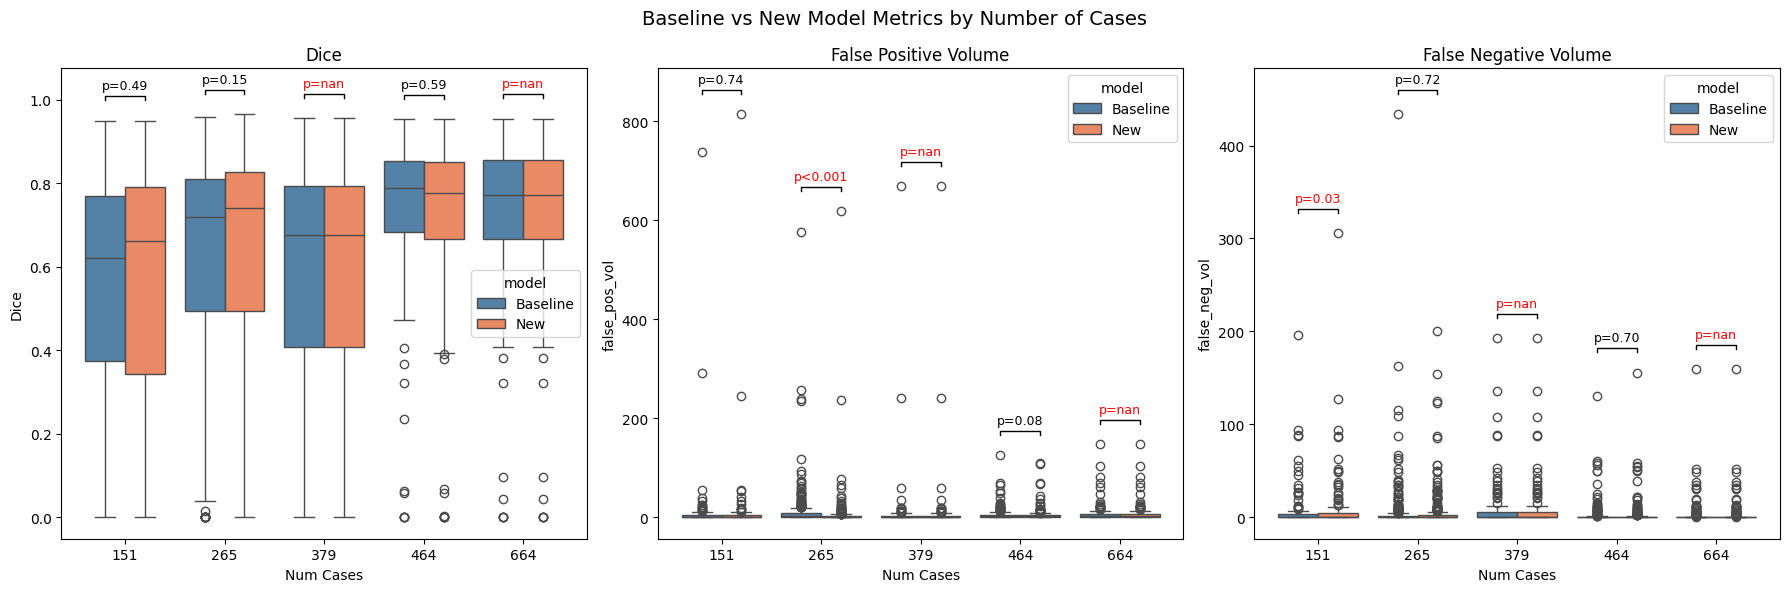

In [19]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# aggregate all_cases_diff by case_name to handle any remaining duplicates
all_cases_diff_agg = all_cases_diff.groupby(['case_name', 'num_cases', 'tracer', 'diseased']).agg(
    {'Dice_baseline': 'mean', 'Dice_new': 'mean',
     'false_pos_vol_baseline': 'mean', 'false_pos_vol_new': 'mean',
     'false_neg_vol_baseline': 'mean', 'false_neg_vol_new': 'mean'}
).reset_index()

metrics = ['Dice', 'false_pos_vol', 'false_neg_vol']
metric_labels = ['Dice', 'False Positive Volume', 'False Negative Volume']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Baseline vs New Model Metrics by Number of Cases', fontsize=14)

for ax, metric, label in zip(axes, metrics, metric_labels):
    # melt into long format for seaborn
    plot_data = all_cases_diff_agg.melt(
        id_vars=['case_name', 'num_cases', 'tracer', 'diseased'],
        value_vars=[f'{metric}_baseline', f'{metric}_new'],
        var_name='model',
        value_name=metric
    )
    plot_data['model'] = plot_data['model'].map({
        f'{metric}_baseline': 'Baseline',
        f'{metric}_new': 'New'
    })

    sns.boxplot(
        data=plot_data,
        x='num_cases',
        y=metric,
        hue='model',
        ax=ax,
        palette={'Baseline': 'steelblue', 'New': 'coral'}
    )
    ax.set_title(label)
    ax.set_xlabel('Num Cases')
    ax.set_ylabel(metric)

    # pairwise t-test per num_cases group
    num_cases_groups = sorted(all_cases_diff_agg['num_cases'].unique())
    for i, num_cases in enumerate(num_cases_groups):
        group = all_cases_diff_agg[all_cases_diff_agg['num_cases'] == num_cases]

        baseline_vals = group[f'{metric}_baseline'].dropna()
        new_vals = group.loc[baseline_vals.index, f'{metric}_new'].dropna()

        # align indices after dropna
        common_idx = baseline_vals.index.intersection(new_vals.index)
        baseline_vals = baseline_vals.loc[common_idx]
        new_vals = new_vals.loc[common_idx]

        t_stat, p_val = stats.ttest_rel(baseline_vals, new_vals)

        # get y position for annotation
        y_max = plot_data[plot_data['num_cases'] == num_cases][metric].max()
        y_range = plot_data[metric].max() - plot_data[metric].min()
        y_pos = y_max + y_range * 0.05

        # format p-value
        if p_val < 0.001:
            p_text = 'p<0.001'
        elif p_val < 0.01:
            p_text = f'p={p_val:.3f}'
        else:
            p_text = f'p={p_val:.2f}'

        # draw bracket and p-value
        x_left = i - 0.2
        x_right = i + 0.2
        ax.plot([x_left, x_left, x_right, x_right],
                [y_pos, y_pos + y_range * 0.01, y_pos + y_range * 0.01, y_pos],
                color='black', linewidth=1)
        ax.text(i, y_pos + y_range * 0.02, p_text,
                ha='center', va='bottom', fontsize=9,
                color='black' if p_val >= 0.05 else 'red')

plt.tight_layout()
plt.show()

In [ ]:
# create box plots


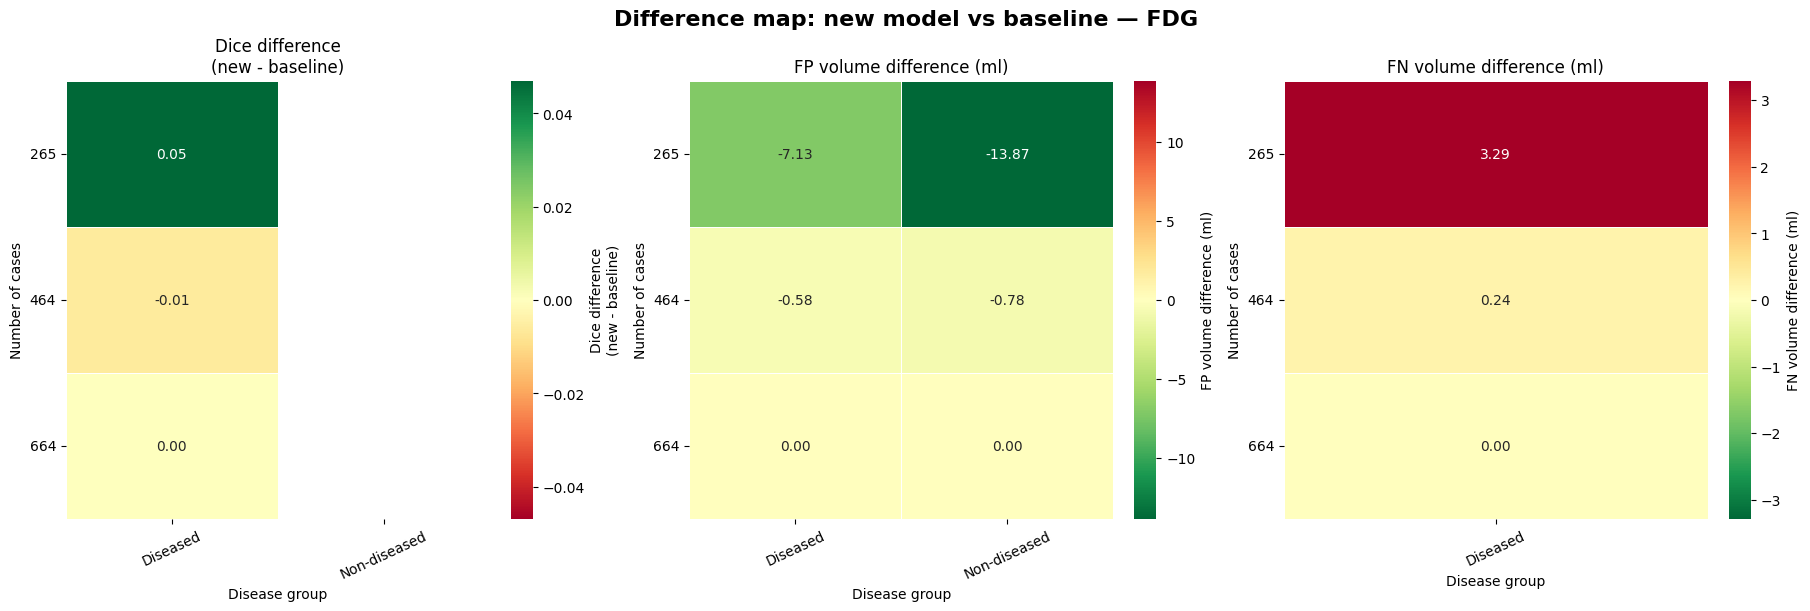

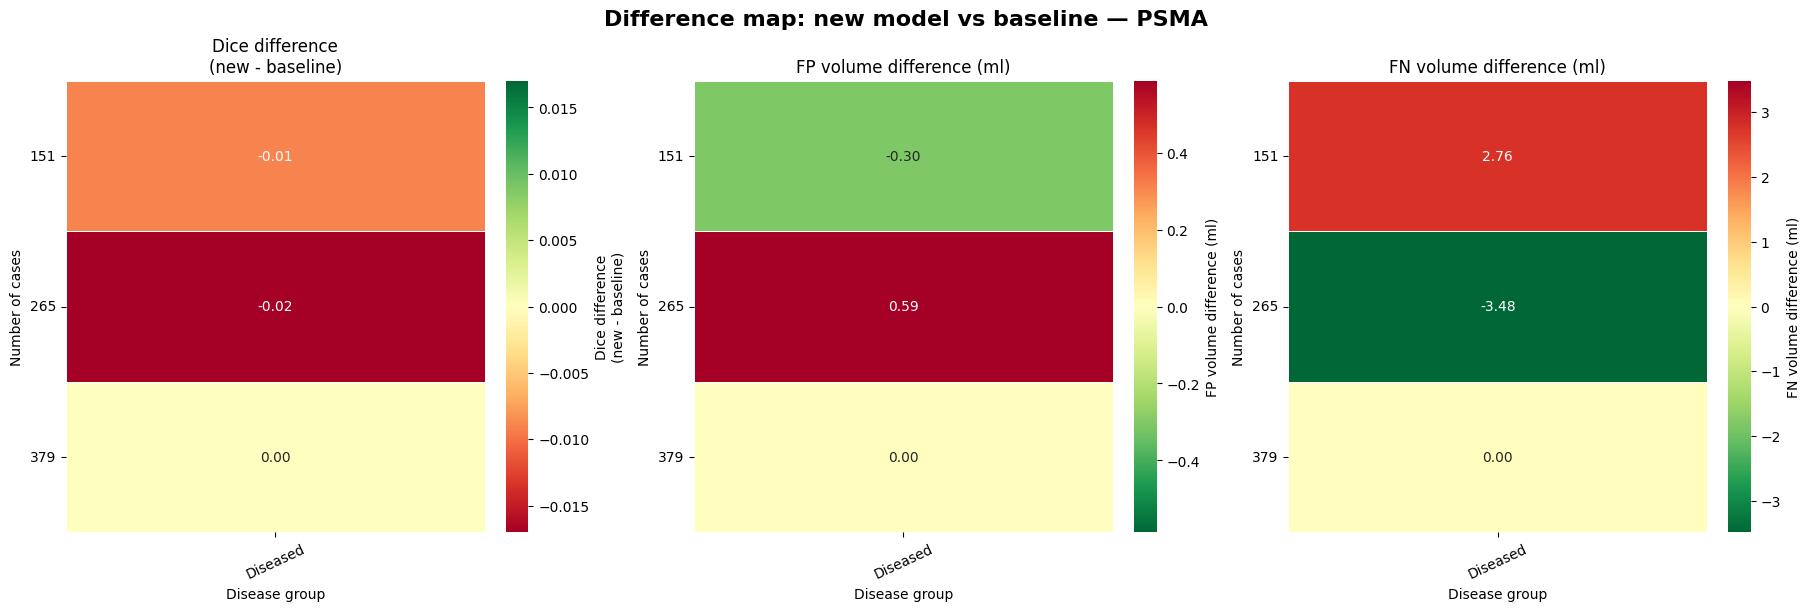

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

all_cases_diff_grouped_reset = all_cases_diff_grouped.reset_index().copy()
all_cases_diff_grouped_reset['group_label'] = all_cases_diff_grouped_reset.apply(
    lambda row: f"{'Diseased' if row['diseased'] else 'Non-diseased'}",
    axis=1,
)

metric_specs = [
    ('Dice_diff',          'Dice difference\n(new - baseline)',      'RdYlGn',   False),  # include_nondiseased
    ('false_pos_vol_diff', 'FP volume difference (ml)',              'RdYlGn_r', False),
    ('false_neg_vol_diff', 'FN volume difference (ml)',              'RdYlGn_r', True),   # exclude non-diseased
]

tracers = sorted(all_cases_diff_grouped_reset['tracer'].unique())

for tracer in tracers:
    tracer_data = all_cases_diff_grouped_reset[all_cases_diff_grouped_reset['tracer'] == tracer]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    fig.suptitle(f'Difference map: new model vs baseline — {tracer}', fontsize=16, fontweight='bold')

    for ax, (metric, title, cmap, exclude_nondiseased) in zip(axes, metric_specs):
        # Filter data for this tracer
        plot_data = tracer_data.copy()
        if exclude_nondiseased:
            plot_data = plot_data[plot_data['group_label'] == 'Diseased']

        # Only keep groups that actually exist in this tracer's data
        available_groups = plot_data['group_label'].unique()
        group_order = [g for g in ['Diseased', 'Non-diseased'] if g in available_groups]

        # Only keep num_cases rows that have data for this tracer
        case_order = sorted(plot_data['num_cases'].unique())

        pivot = (
            plot_data
            .pivot_table(index='num_cases', columns='group_label', values=metric, aggfunc='mean')
            .reindex(index=case_order, columns=group_order)
        )

        values = pivot.to_numpy(dtype=float)
        finite_values = values[np.isfinite(values)]

        if finite_values.size and np.max(np.abs(finite_values)) > 0:
            max_abs = float(np.max(np.abs(finite_values)))
            norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
        else:
            norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

        # Scale figure height dynamically to number of rows
        n_rows = len(case_order)
        n_cols = len(group_order)

        sns.heatmap(
            pivot,
            ax=ax,
            cmap=cmap,
            norm=norm,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': title},
        )
        ax.set_title(title)
        ax.set_xlabel('Disease group')
        ax.set_ylabel('Number of cases')
        ax.tick_params(axis='x', rotation=25)
        ax.tick_params(axis='y', rotation=0)

    plt.show()

In [19]:
all_cases_baseline.groupby(['diseased', 'tracer', 'num_cases']).agg({'Dice': 'mean', 'false_pos_vol': 'mean', 'false_neg_vol': 'mean', 'case_name': 'count'}).round(3)


Dice  false_pos_vol  false_neg_vol  case_name
diseased tracer num_cases                                                
False    FDG    265          NaN         18.097          0.000        102
                464          NaN          7.996          0.000        102
                664          NaN          8.747          0.000        102
True     FDG    265        0.657          9.857          4.151         97
                464        0.711          3.983          7.449         97
                664        0.714          4.203          6.822         97
         PSMA   151        0.552         13.058          8.326        122
                265        0.579          9.389         13.471        122
                379        0.581         10.747          9.920        122

In [22]:
all_cases = all_cases.loc[all_cases['num_cases'] > 70]
all_cases.groupby(['diseased', 'tracer', 'num_cases']).agg({'Dice': 'mean', 'false_pos_vol': 'mean', 'false_neg_vol': 'mean', 'case_name': 'count'}).round(3)


Dice  false_pos_vol  false_neg_vol  case_name
diseased tracer num_cases                                                
False    FDG    265          NaN          4.224          0.000        102
                464          NaN          7.216          0.000        102
                664          NaN          8.747          0.000        102
True     FDG    265        0.703          2.725          7.442         97
                464        0.705          3.404          7.692         97
                664        0.714          4.203          6.822         97
         PSMA   151        0.543         12.755         11.084        122
                265        0.562          9.976          9.989        122
                379        0.581         10.747          9.920        122

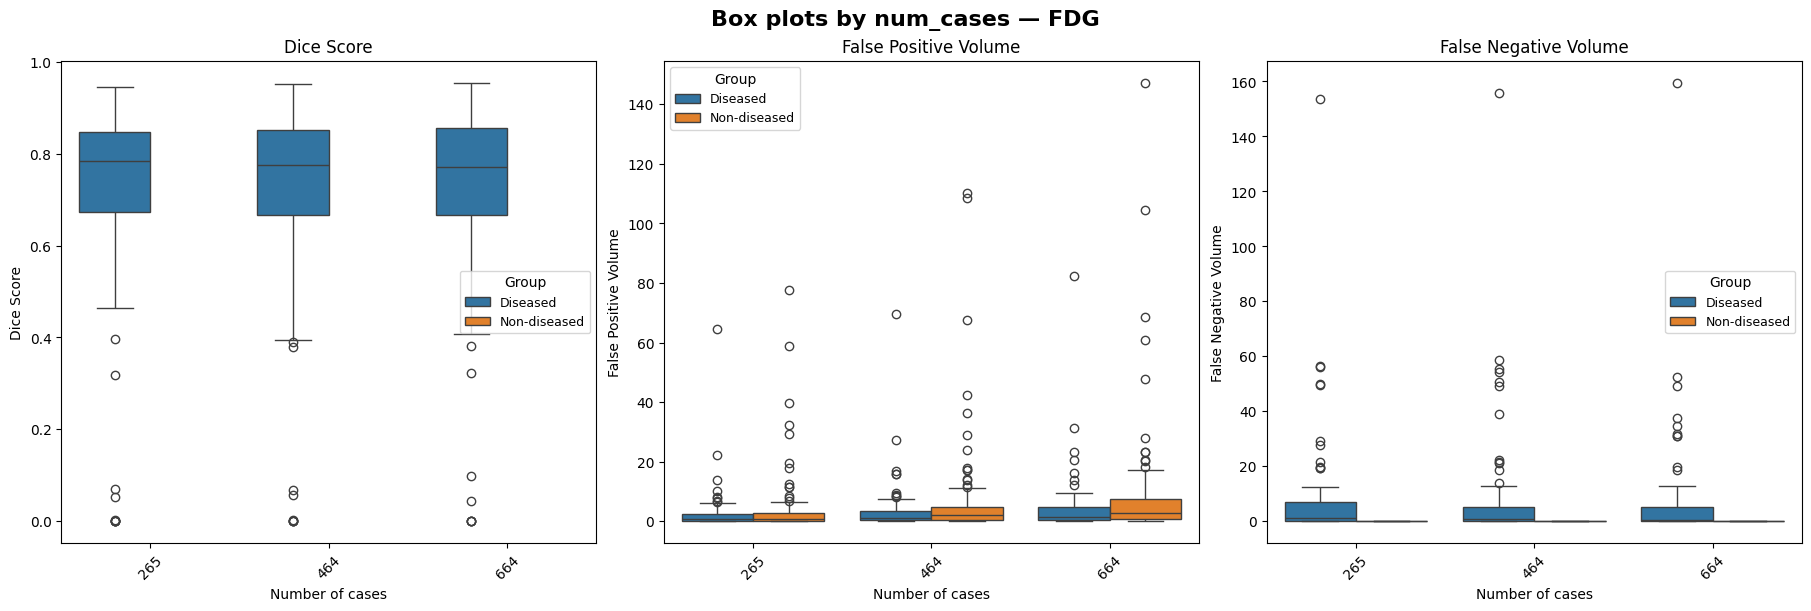

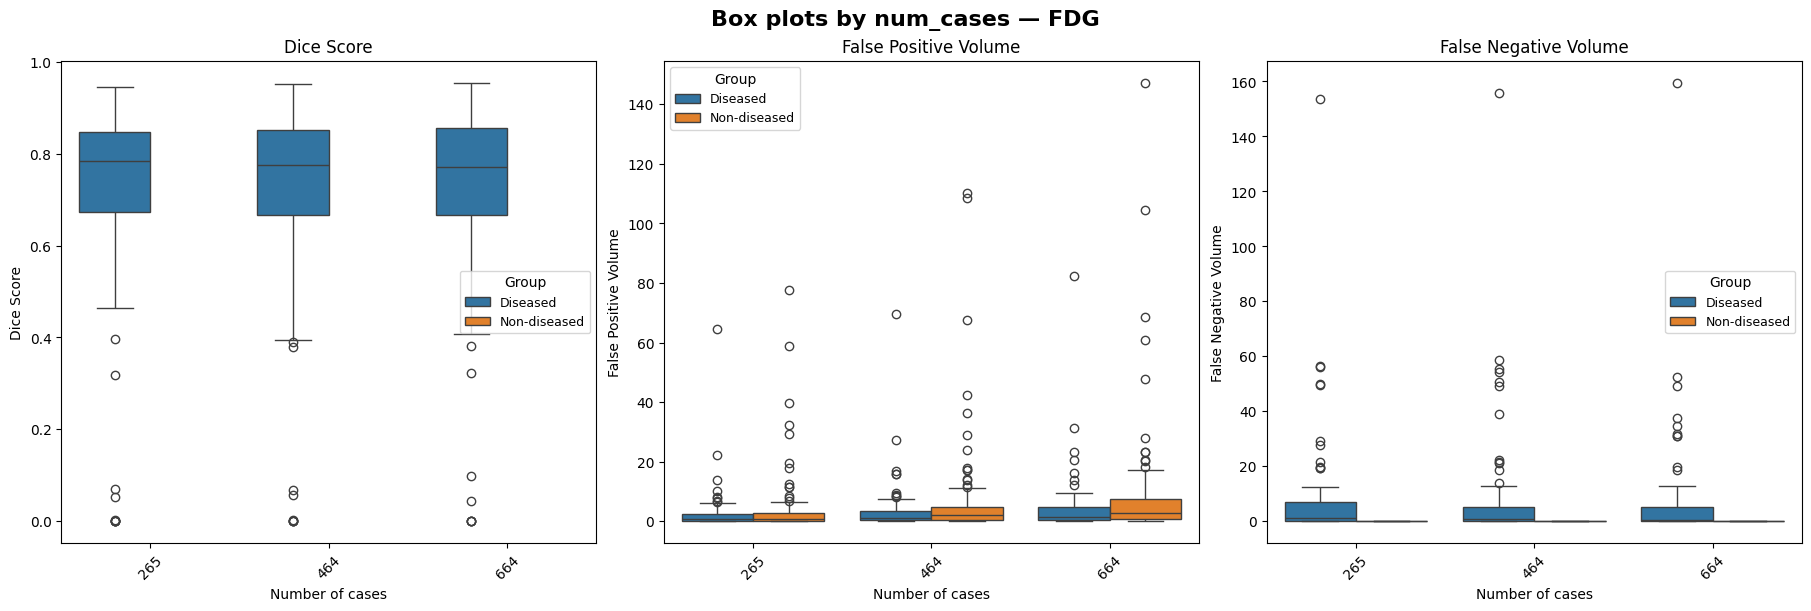

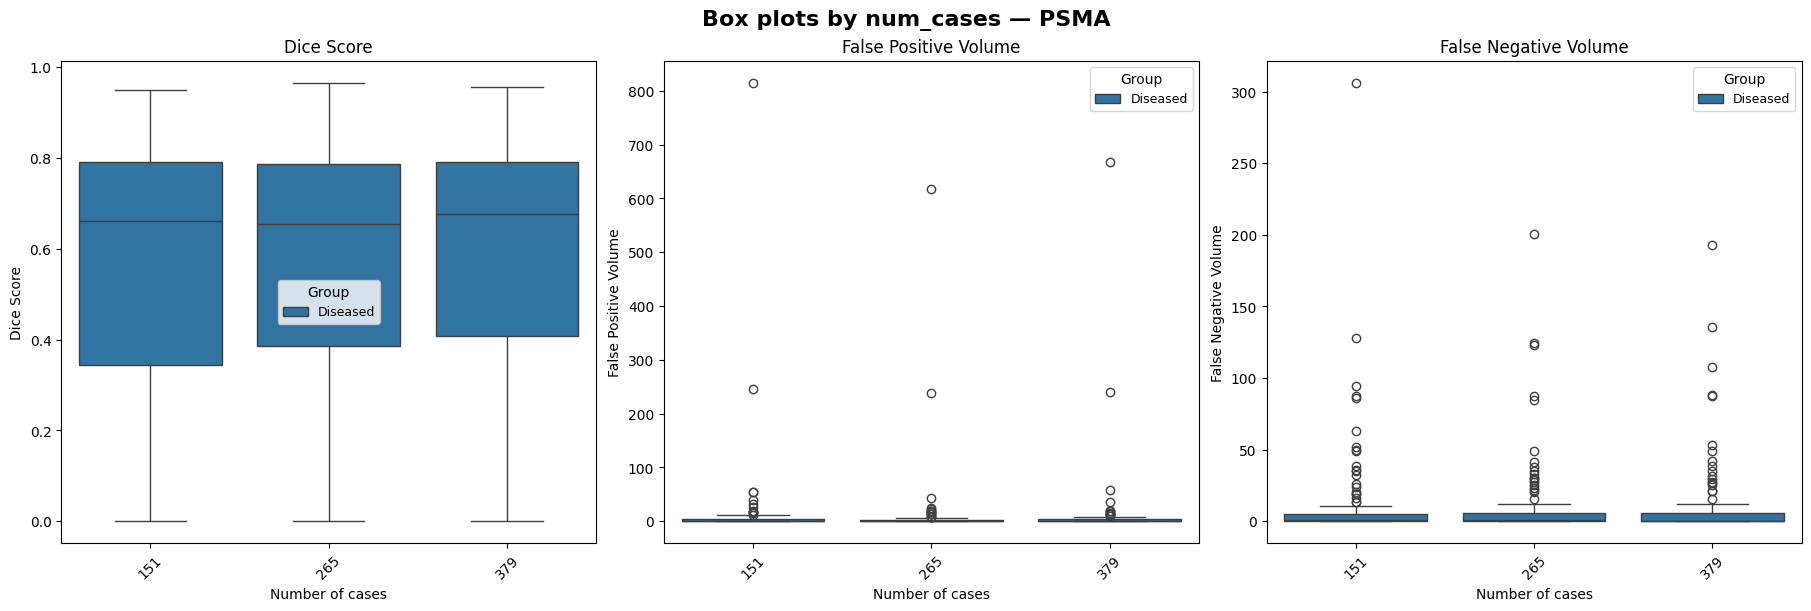

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

box_data = all_cases.loc[all_cases['num_cases'] > 70].copy()
box_data['group_label'] = np.where(box_data['diseased'], 'Diseased', 'Non-diseased')

metric_specs = [
    ('Dice', 'Dice Score'),
    ('false_pos_vol', 'False Positive Volume'),
    ('false_neg_vol', 'False Negative Volume'),
]

for tracer in sorted(box_data['tracer'].unique()):
    tracer_data = box_data[box_data['tracer'] == tracer].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    fig.suptitle(f'Box plots by num_cases — {tracer}', fontsize=16, fontweight='bold')

    for ax, (metric, ylabel) in zip(axes, metric_specs):
        sns.boxplot(
            data=tracer_data,
            x='num_cases',
            y=metric,
            hue='group_label',
            ax=ax,
            dodge=True,
        )
        ax.set_title(ylabel)
        ax.set_xlabel('Number of cases')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Group', fontsize=9)

    plt.savefig(f'boxplot_{tracer}.png', dpi=150, bbox_inches='tight')
    plt.show()

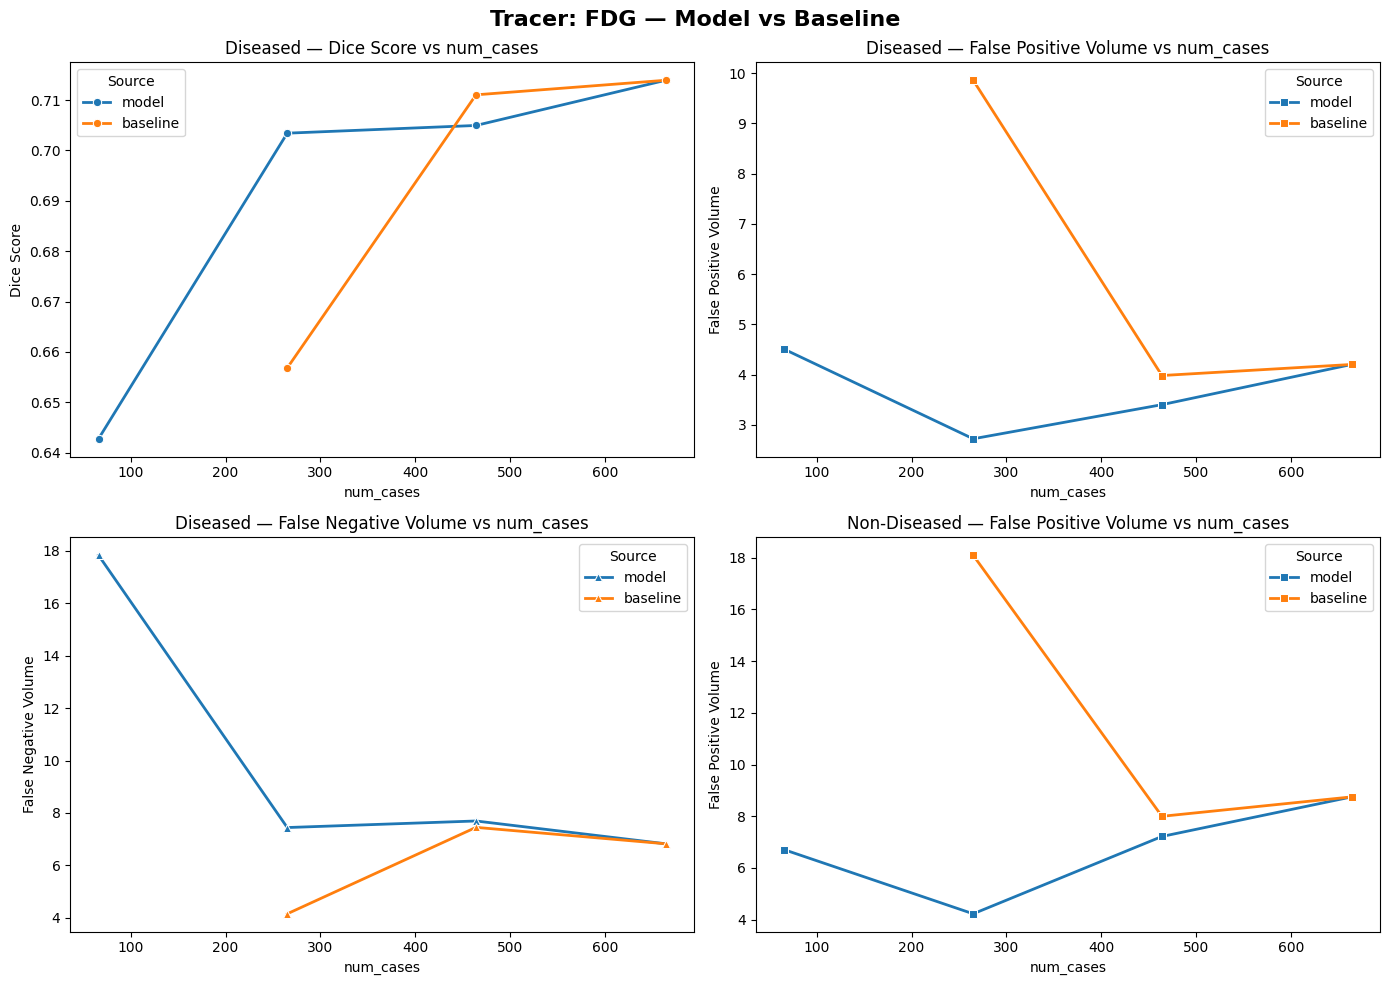

/tmp/ipykernel_2975470/1050365784.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Source")


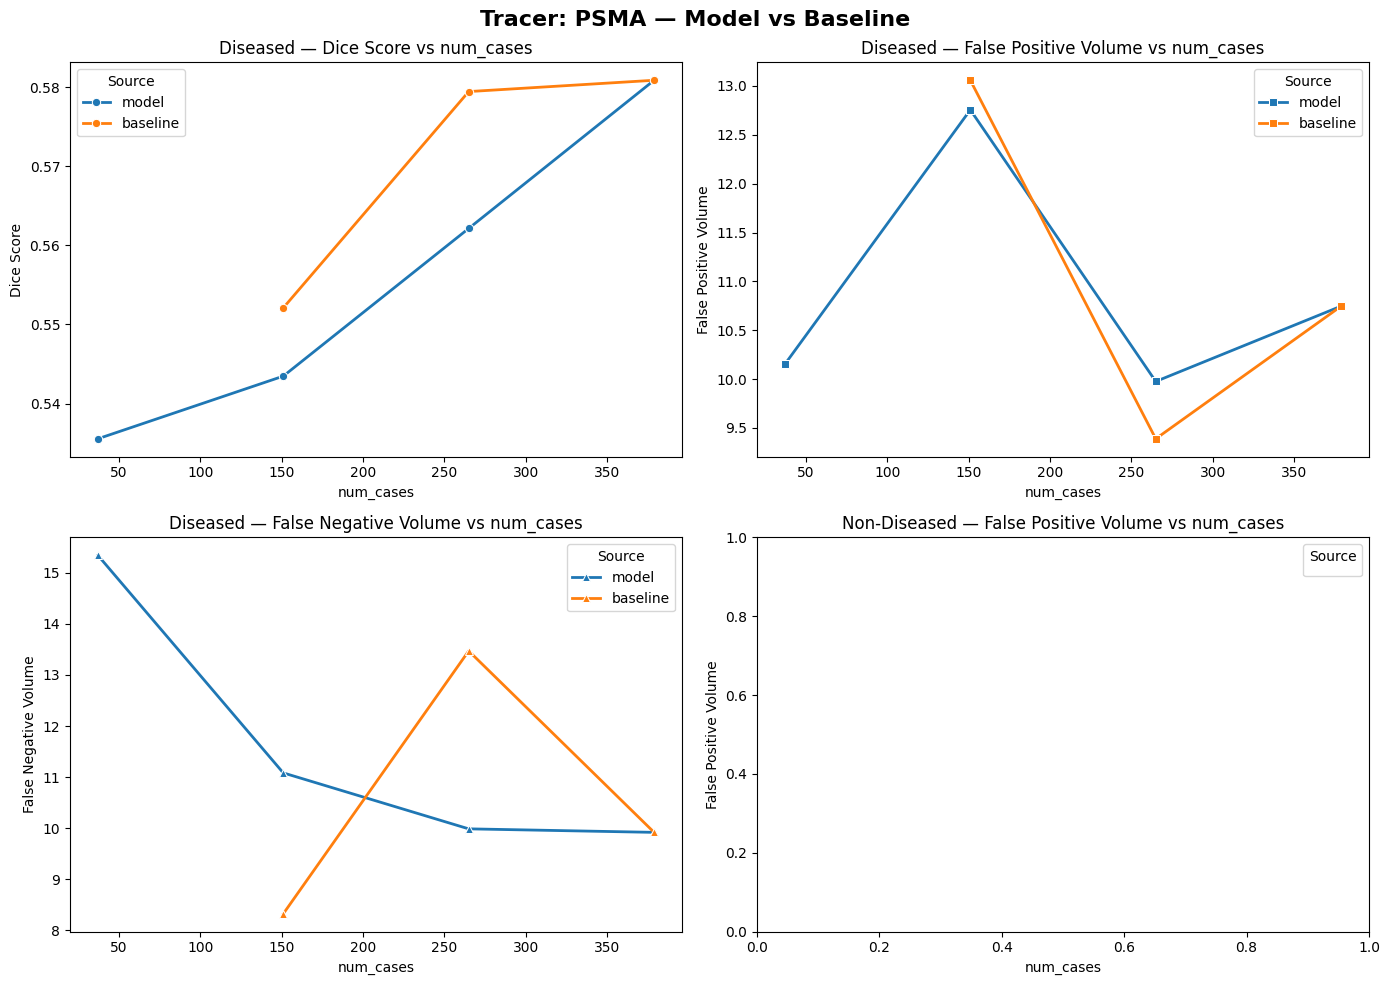

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prep both dataframes with a source label
all_cases['source'] = 'model'
all_cases_baseline['source'] = 'baseline'

combined = pd.concat([all_cases, all_cases_baseline], ignore_index=True)

TRACERS = combined['tracer'].unique()

for tracer in TRACERS:
    sub = combined[combined['tracer'] == tracer].copy()
    
    diseased_sub    = sub[sub['diseased'] == True]
    nondiseased_sub = sub[sub['diseased'] == False]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Tracer: {tracer} — Model vs Baseline", fontsize=16, fontweight="bold")

    # 0,0 — Dice vs num_cases (diseased)
    ax = axes[0, 0]
    sns.lineplot(data=diseased_sub, x="num_cases", y="Dice",
                 hue="source", marker="o", ax=ax, linewidth=2, errorbar=None)
    ax.set_title("Diseased — Dice Score vs num_cases")
    ax.set_xlabel("num_cases")
    ax.set_ylabel("Dice Score")
    ax.legend(title="Source")

    # 0,1 — False Positive Volume (diseased)
    ax = axes[0, 1]
    sns.lineplot(data=diseased_sub, x="num_cases", y="false_pos_vol",
                 hue="source", marker="s", ax=ax, linewidth=2, errorbar=None)
    ax.set_title("Diseased — False Positive Volume vs num_cases")
    ax.set_xlabel("num_cases")
    ax.set_ylabel("False Positive Volume")
    ax.legend(title="Source")

    # 1,0 — False Negative Volume (diseased)
    ax = axes[1, 0]
    sns.lineplot(data=diseased_sub, x="num_cases", y="false_neg_vol",
                 hue="source", marker="^", ax=ax, linewidth=2, errorbar=None)
    ax.set_title("Diseased — False Negative Volume vs num_cases")
    ax.set_xlabel("num_cases")
    ax.set_ylabel("False Negative Volume")
    ax.legend(title="Source")

    # 1,1 — False Positive Volume (non-diseased)
    ax = axes[1, 1]
    sns.lineplot(data=nondiseased_sub, x="num_cases", y="false_pos_vol",
                 hue="source", marker="s", ax=ax, linewidth=2, errorbar=None)
    ax.set_title("Non-Diseased — False Positive Volume vs num_cases")
    ax.set_xlabel("num_cases")
    ax.set_ylabel("False Positive Volume")
    ax.legend(title="Source")

    plt.tight_layout()
    plt.savefig(f"comparison_{tracer}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [15]:

lesion_metrics_df = pd.read_csv('../lesion_metrics.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../lesion_metrics.csv'